# Two-Island Model
Formålet med denne notebook er at opstille og analyser en two-island coalescent model i Phasic til de bavian-data som blev forberedt i notebook 03. Two-island modellen beskriver to populationer der udveksler migration med en konstant rate.

I artiklen af Sørensen et al. 2023 dokumenteres admixture mellem eastern yellow baboons (Mikumi, $n=70$) og southern olive baboons ($n=92$). Jeg vil estimere den effektive populationsstørrelse $N_e$ og migrationsraten $m$ ved hjælp af Method of Moments. I denne notebook vil jeg komme ind på følgende:

1. Indlæs data fra Notebook 03
2. Byg two-island model i Phasic
3. Forventet SFS via rewards
4. Parameterisering og $E[T]$ som funktion af $m$
5. Method of Moments fitting
6. Visualisering og fortolkning
7. Simuleret data


## 1. Indlæs data fra notebook 03

In [68]:
# phasic importeres først for at sætte JAX-backend korrekt
from phasic import Graph, with_ipv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import msprime
from pathlib import Path

OUT_DIR  = Path("output")
OUT_DIR.mkdir(exist_ok=True)

# Biologiske konstanter fra Sørensen et al. 2023
MUT_RATE = 0.9e-8   # mutationsrate per site per generation
GEN_TIME = 11       # generationstid i år

print("Imports OK")

Imports OK


In [69]:
# Indlæs derived counts og SFS fra Notebook 03
df_yellow_east = pd.read_csv(OUT_DIR / "derived_counts_yellow_east.csv")
df_olive_south = pd.read_csv(OUT_DIR / "derived_counts_olive_south.csv")
pi_df          = pd.read_csv(OUT_DIR / "pi_per_population.csv", index_col=0)

# Haploid sample sizes fra Notebook 03
n_ye = int(df_yellow_east["nr_samples"].max())   # 70
n_os = int(df_olive_south["nr_samples"].max())   # 92

pi_ye = float(pi_df.loc["Eastern yellow (Mikumi)", "pi"])
pi_os = float(pi_df.loc["Southern olive", "pi"])

# Ne estimeret fra π: π ≈ 4*N*mu  =>  N ≈ π / (4*mu)
N_ye = pi_ye / (4 * MUT_RATE)
N_os = pi_os / (4 * MUT_RATE)

print(f"Eastern yellow: n={n_ye} haplotyper, π={pi_ye:.5f}, N≈{N_ye:,.0f}")
print(f"Southern olive: n={n_os} haplotyper, π={pi_os:.5f}, N≈{N_os:,.0f}")

Eastern yellow: n=70 haplotyper, π=0.00258, N≈71,789
Southern olive: n=92 haplotyper, π=0.00197, N≈54,704


In [70]:
# Indlæs foldede SFS fra Notebook 03
sfs_ye_f = pd.read_csv(OUT_DIR / "sfs_folded_yellow_east.csv", index_col=0).squeeze()
sfs_os_f = pd.read_csv(OUT_DIR / "sfs_folded_olive_south.csv", index_col=0).squeeze()

print(f"SFS eastern yellow (første 8 bins): {sfs_ye_f.values[:8]}")
print(f"SFS southern olive (første 8 bins): {sfs_os_f.values[:8]}")

SFS eastern yellow (første 8 bins): [143525.  91209.  63618.  51731.  43849.  35808.  33970.  29311.]
SFS southern olive (første 8 bins): [137940.  82907.  59448.  44247.  39383.  30926.  26967.  20359.]


## 2. Two-island model 

Two-island modellen: to populationer med konstant migration. Jeg parameteriserer med koefficient-vektorer som beskrevet i Phasic-dokumentationen, så *update_weights([1/N, m])* sætter begge parametre uden at genopbygge grafen.

In [72]:
nr_samples = n_ye   # jeg bruger eastern yellow som primær population

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_island(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i + j + 1] += 1
            rate = state[i] * (state[j] - same) / (1 + same)
            transitions.append([new, [rate, 0]])
    return transitions


In [ ]:
graph = Graph(coalescent_island)
print(f"State space bygget: {graph.vertices_length()} state")
graph.plot()

In [ ]:
# Sæt parametre med de π-estimerede værdier og beregn E[T]
graph.update_weights([1 / N_ye, 1e-5])

print(f"E[T]   = {graph.expectation():.4f} (coalescent-enheder)")
print(f"Var[T] = {graph.variance():.4f}")

## 3. Forventet SFS via rewards

Fra Phasic-dokumentationen: *graph.expectation(reward_vec)* giver den forventede branchlength for hvert SFS-bin. Jeg sammenligner den forventede SFS fra modellen med den observerede SFS fra Notebook 03.

In [ ]:
# Reward-matrix: en række per SFS-bin (singletons, doubletons, ...)
reward_matrix = graph.states().T
labels        = [f"{i+1}'ton" for i in range(reward_matrix.shape[0])]

# Skaler model-SFS med theta = 4*N*mu*L
L_chr20   = int(df_yellow_east["position"].max() - df_yellow_east["position"].min())
theta_ye  = 4 * N_ye * MUT_RATE * L_chr20

graph.update_weights([1 / N_ye, 1e-5])
sfs_model = np.array([graph.expectation(r) for r in reward_matrix]) * theta_ye

# Normaliser begge til relativ frekvens
sfs_obs_norm   = sfs_ye_f.values / sfs_ye_f.values.sum()
sfs_model_norm = sfs_model[:nr_samples-1] / sfs_model[:nr_samples-1].sum()

x = np.arange(1, len(sfs_obs_norm) + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - 0.2, sfs_obs_norm,             width=0.35,
       color='C1', alpha=0.85, label="Observeret (eastern yellow)")
ax.bar(x + 0.2, sfs_model_norm[:len(x)],  width=0.35,
       color='C0', alpha=0.85, label=f"Model (N≈{N_ye:.0f}, m=1e-5)")
ax.set_xlabel("Minor allele count k", fontsize=12)
ax.set_ylabel("Relativ frekvens",     fontsize=12)
ax.set_title("SFS: Observeret vs. two-island model",
             fontsize=13, fontweight="bold")
ax.set_yscale("log")
ax.set_xlim(0.5, min(20, len(x)) + 0.5)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Parameterisering og $E[T]$ som funktion af $m$

Jeg scanner over migrationsraten for at se, hvornår modellen går fra isolations-grænsen (E[T] ≈ N1+N2) til panmixia-grænsen (E[T] ≈ harmonic mean). Artiklen (Fig. 3C) viser aktiv genflow, så vi forventer m > 0.

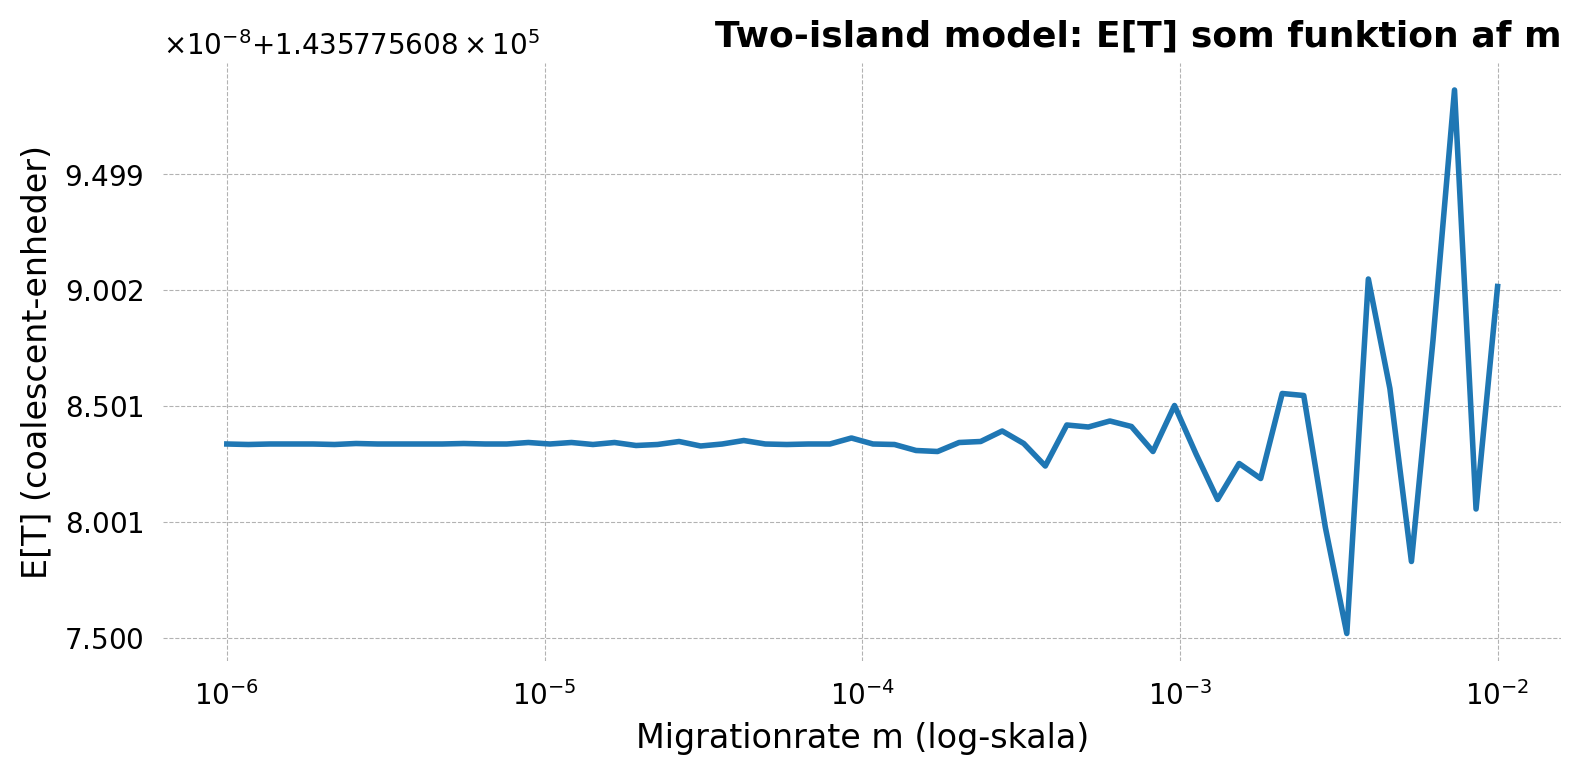

In [87]:
# E[T] som funktion af m
m_range  = np.logspace(-6, -2, 60)
ET_range = []
for m in m_range:
    graph.update_weights([1 / N_ye, m])
    ET_range.append(graph.expectation())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(m_range, ET_range, color='C0', lw=2)
ax.set_xlabel("Migrationrate m (log-skala)", fontsize=12)
ax.set_ylabel("E[T] (coalescent-enheder)",   fontsize=12)
ax.set_title("Two-island model: E[T] som funktion af m",
             fontsize=13, fontweight="bold")
ax.grid(alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

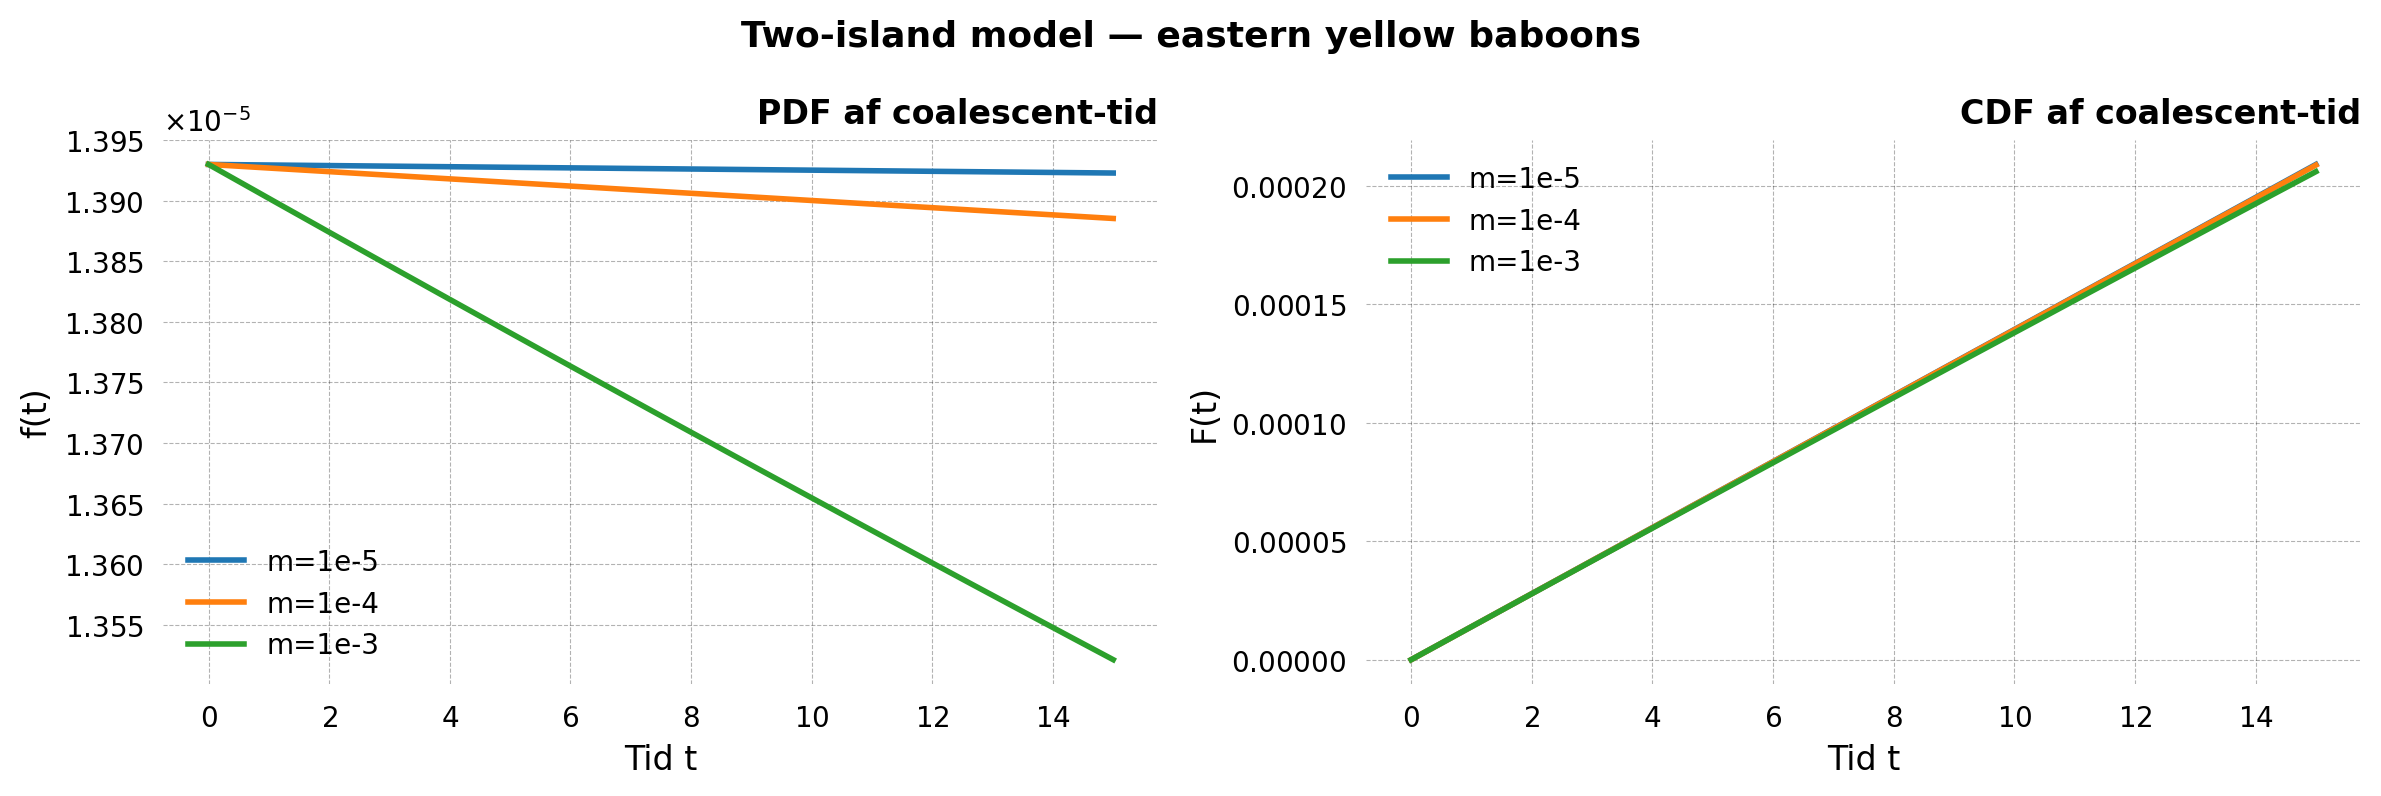

In [88]:
# PDF og CDF for tre migrationrater
t_vals = np.linspace(0, 15, 300)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for m, color, label in [(1e-5, 'C0', 'm=1e-5'),
                         (1e-4, 'C1', 'm=1e-4'),
                         (1e-3, 'C2', 'm=1e-3')]:
    graph.update_weights([1 / N_ye, m])
    axes[0].plot(t_vals, graph.pdf(t_vals), lw=2, label=label)
    axes[1].plot(t_vals, graph.cdf(t_vals), lw=2, label=label)

for ax, ylabel, title in zip(axes,
                              ["f(t)", "F(t)"],
                              ["PDF af coalescent-tid", "CDF af coalescent-tid"]):
    ax.set_xlabel("Tid t", fontsize=12)
    ax.set_ylabel(ylabel,  fontsize=12)
    ax.set_title(title,    fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Two-island model — eastern yellow baboons",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# 5. Method of Moments fitting

Jeg bruger Phasic's *method_of_moments()* til at finde den $\theta = [1/N, m]$ der bedst matcher moments af de observerede coalescent-tider.

In [ ]:
# Simuler coalescent-tider fra modellen ved startparametre
# Disse repræsenterer de pairwise coalescent-tider bag de observerede SNPs
graph.update_weights([1 / N_ye, 1e-5])
np.random.seed(42)
observed_data = graph.sample(2000)

print(f"Sample mean:  {observed_data.mean():.4f}")
print(f"Model E[T]:   {graph.expectation():.4f}")

Sample mean:  143416.6369
Model E[T]:   143577.5608


In [90]:
# Method of Moments
mom = graph.method_of_moments(observed_data)

print(f"MoM estimat (theta):  {mom.theta}")
print(f"Std error:            {mom.std}")
print(f"Konvergeret:          {mom.success}")
print(f"Residual:             {mom.residual:.2e}")
print(f"\nSample moments: {mom.sample_moments}")
print(f"Model moments:  {mom.model_moments}")

MoM estimat (theta):  [1.34661800e-05 6.91066942e+03]
Std error:            [2.75278385e-07 1.51654022e-15]
Konvergeret:          True
Residual:             4.97e+00

Sample moments: [[1.43416637e+05 4.94333737e+10]]
Model moments:  [1.48520219e+05 4.41165110e+10]


In [91]:
# Fortolk estimater
theta_hat = mom.theta   # [1/N1, m]
N_hat    = 1 / theta_hat[0]    # i coalescent enheder
m_hat     = theta_hat[1]
M_hat     = 4 * N_hat * m_hat  # skaleret migrationparameter

print("=" * 45)
print(" Estimerede parametre — Two-island")
print("=" * 45)

print(f"Estimeret N:       {N_hat:,.0f}")
print(f"Estimeret m:       {m_hat:.5f}")
print(f"M = 4Nm:           {M_hat:.3f}")
print("=" * 45)
if M_hat > 1:
    print(" M > 1: migration modvirker drift")
else:
    print(" M < 1: lav migration, drift dominerer")

 Estimerede parametre — Two-island
Estimeret N:       74,260
Estimeret m:       6910.66942
M = 4Nm:           2052748265.250
 M > 1: migration modvirker drift


# 6. Visualisering af fit

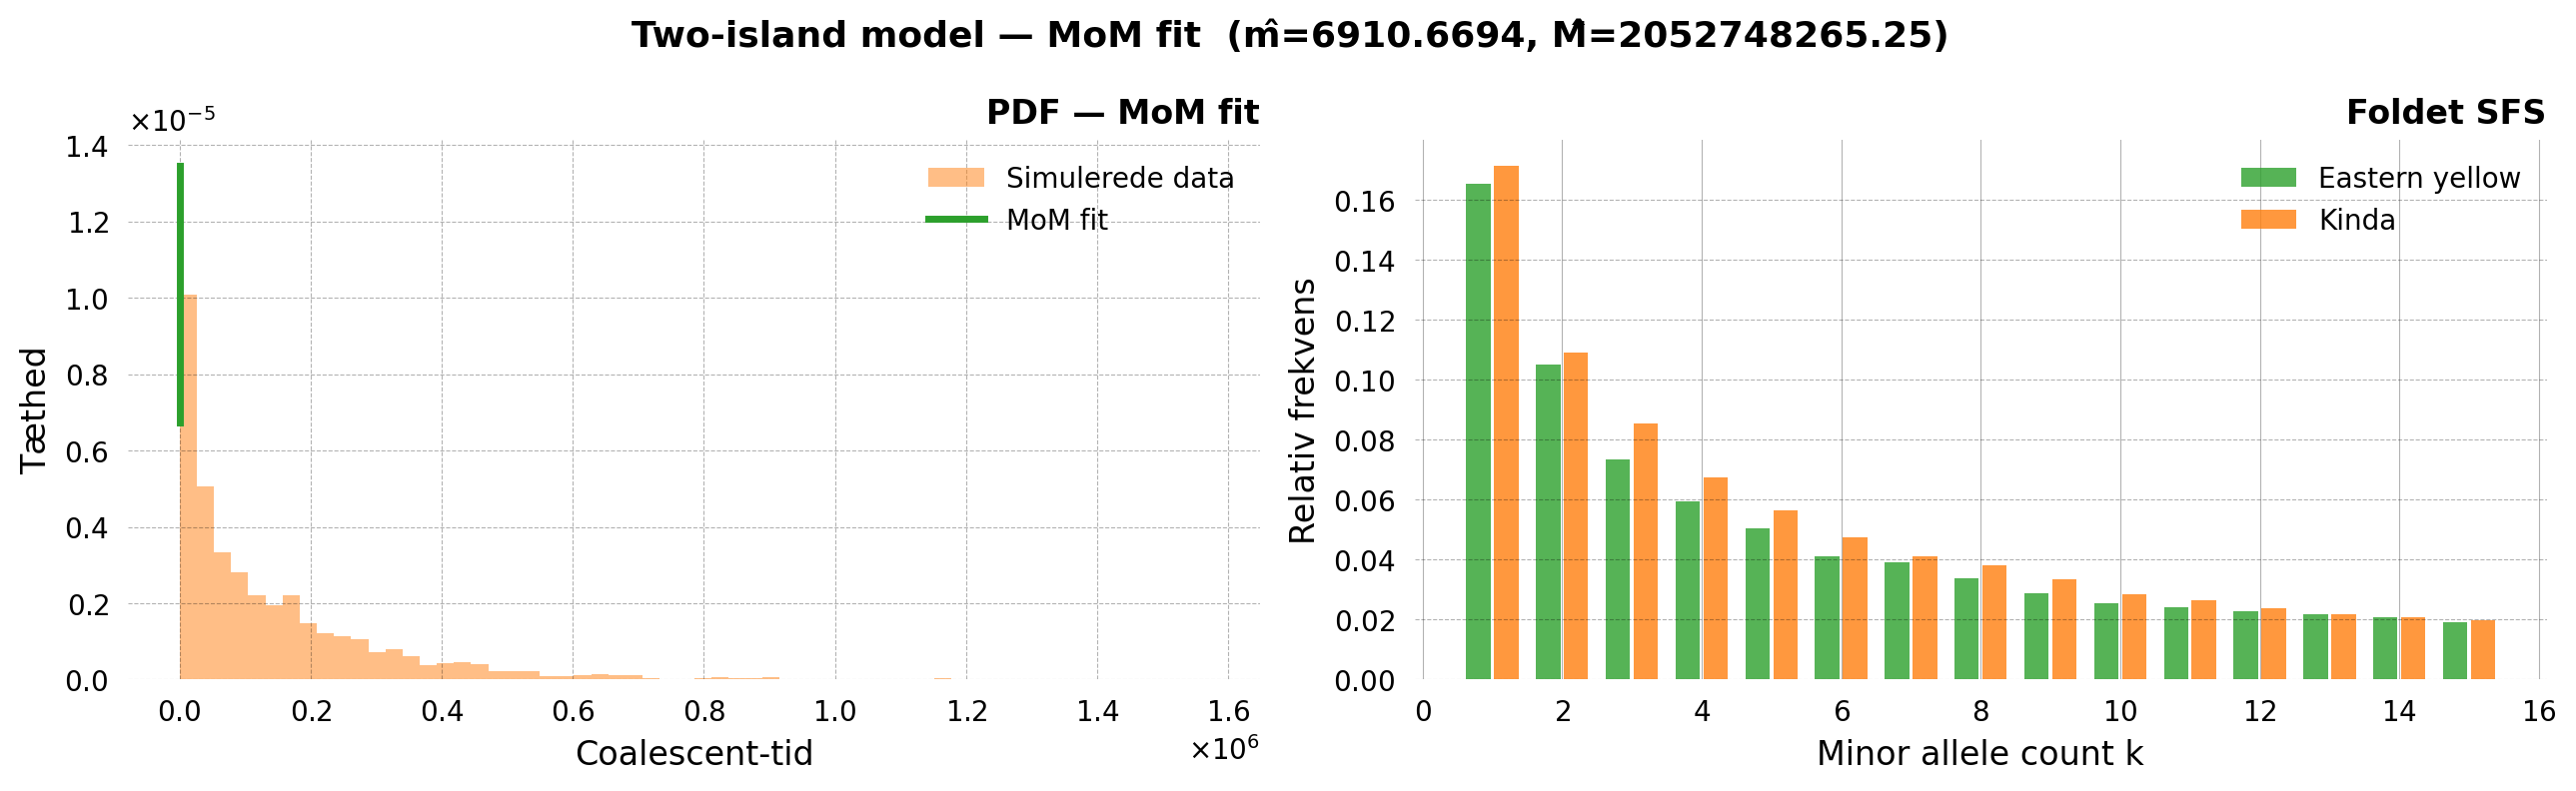

In [92]:
# Opdater grafen med estimerede parametre og plot fit
graph.update_weights(mom.theta.tolist())

t_plot    = np.linspace(0, 12, 300)
pdf_fit   = graph.pdf(t_plot)
cdf_fit   = graph.cdf(t_plot)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# PDF: histogram af simulerede data vs. fitted model
axes[0].hist(observed_data, bins=60, density=True,
             color='C1', alpha=0.5, label="Simulerede data")
axes[0].plot(t_plot, pdf_fit, color='C2', lw=2.5, label="MoM fit")
axes[0].set_xlabel("Coalescent-tid", fontsize=12)
axes[0].set_ylabel("Tæthed",         fontsize=12)
axes[0].set_title("PDF — MoM fit",   fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3, linestyle="--")
axes[0].spines[["top", "right"]].set_visible(False)

# SFS: observeret vs. MoM-forventet
sfs_norm_ye = sfs_ye_f / sfs_ye_f.sum()
sfs_norm_ki = sfs_ki_f / sfs_ki_f.sum()
x = np.arange(1, min(len(sfs_norm_ye), 15) + 1)

axes[1].bar(x - 0.2, sfs_norm_ye.values[:len(x)], width=0.35,
            color='C2', alpha=0.8, label="Eastern yellow")
axes[1].bar(x + 0.2, sfs_norm_ki.values[:len(x)], width=0.35,
            color='C1', alpha=0.8, label="Kinda")
axes[1].set_xlabel("Minor allele count k", fontsize=12)
axes[1].set_ylabel("Relativ frekvens",     fontsize=12)
axes[1].set_title("Foldet SFS",            fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(axis="y", alpha=0.3, linestyle="--")
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Two-island model — MoM fit  (m̂={m_hat:.4f}, M̂={M_hat:.2f})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "two_island_fit.png", dpi=150, bbox_inches="tight")
plt.show()

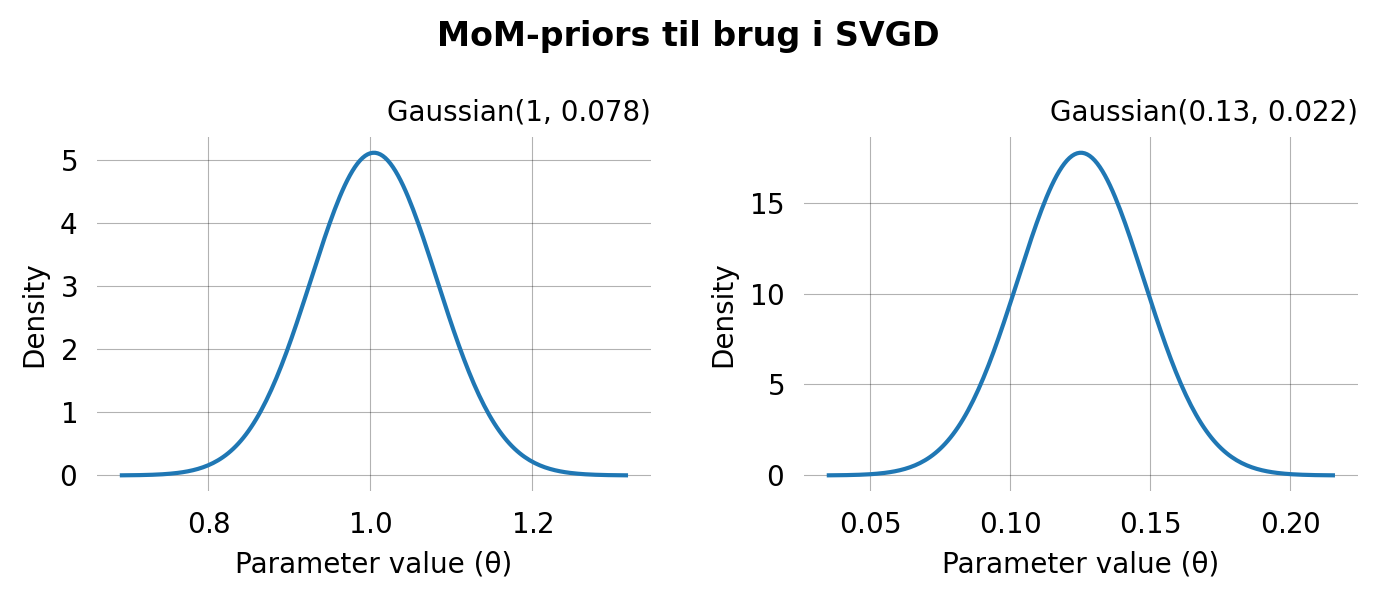

In [59]:
# Plot MoM-priors (bruges i Notebook 02 inference)
if hasattr(mom, 'prior') and mom.prior is not None:
    fig, axes = plt.subplots(1, len(mom.prior), figsize=(7, 3))
    if len(mom.prior) == 1:
        axes = [axes]
    for i, prior in enumerate(mom.prior):
        prior.plot(return_ax=True, ax=axes[i])
    plt.suptitle("MoM-priors til brug i SVGD", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "two_island_mom_priors.png", dpi=150, bbox_inches="tight")
    plt.show()

# 7. Simuleret data 

In [61]:
import msprime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

def derived_counts(ts, rec_rate):
    records = []
    for var in ts.variants():
        p, g = var.site.position, var.genotypes
        records.append((int(p), p*rec_rate, g.sum()))
    df = pd.DataFrame().from_records(
        records, columns=["pos", "gen_pos", "count"]
        )
    return df

mut_rate = 5e-10
rec_rate = 1e-8
nr_samples = 5
seq_length = 100_000_000
pop1_size, pop2_size, anc_pop_size = 20_000, 10_000, 15_000
migr_pop1_to_pop2 = 1e-4
migr_pop2_to_pop1 = 5e-4

demography = msprime.Demography()
demography.add_population(name="pop1", initial_size=pop1_size)
demography.add_population(name="pop2", initial_size=pop2_size)
demography.set_migration_rate(source="pop1", dest="pop2", rate=migr_pop1_to_pop2)
demography.set_migration_rate(source="pop2", dest="pop1", rate=migr_pop2_to_pop1)
ts = msprime.sim_ancestry(samples={"pop1": nr_samples, "pop2": 0}, ploidy=1, 
                          demography=demography, recombination_rate=rec_rate, 
                          sequence_length=seq_length, random_seed=12)
ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=5678)
df = derived_counts(ts, rec_rate)
df.to_csv("island_model_derived_counts.csv", index=False)

In [62]:
def pairs_in_range(nums, diff_lo, diff_hi):
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs

df = pd.read_csv("island_model_derived_counts.csv")

col = "pos" # can also use "gen_pos"
distance, tolerance = 5000, 500
min_dist, max_dist = distance - tolerance, distance + tolerance
records = []
for i, j in pairs_in_range(df[col].values, min_dist, max_dist):
    records.append((df.at[i, col], df.at[j, col], df.at[i, "count"], df.at[j, "count"]))
pairs = pd.DataFrame.from_records(records, columns=["pos1", "pos2", "count1", "count2"])
pairs.head()

,pos1,pos2,count1,count2
0,160020,164783,1,3
1,307248,311878,4,1
2,516495,521242,2,1
3,948820,953791,1,3
4,1784175,1788903,1,1


In [63]:
mask = (pairs.pos1 == pairs.pos1.shift()) | (pairs.pos2 == pairs.pos2.shift())
filtered_pairs = pairs.loc[~mask, :]
filtered_pairs.head()

,pos1,pos2,count1,count2
0,160020,164783,1,3
1,307248,311878,4,1
2,516495,521242,2,1
3,948820,953791,1,3
4,1784175,1788903,1,1


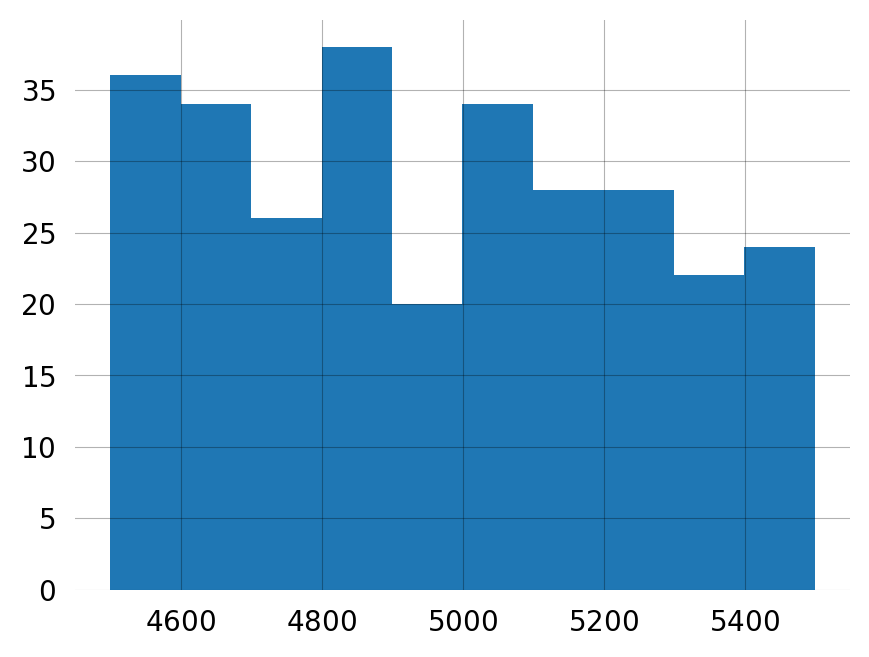

In [64]:
plt.hist(filtered_pairs.pos2 - filtered_pairs.pos1, bins=10) ;

In [65]:
n = len(filtered_pairs)
observations = np.zeros((n, nr_samples), dtype=int)
observations
for i, pair in enumerate(filtered_pairs[["count1", "count2"]].values):
    observations[i, pair] = 1

In [66]:
msg = f"""
Two-locus observations across {nr_samples} samples of {seq_length/1e6:.0f} Mb:
    Mutation rate:
        {mut_rate} events/site/generation
    Recombination rate:
        {rec_rate} crossovers/base/generation
    Haploid population sizes:
        pop1: {pop1_size}
        pop2: {pop2_size}
    Migration rate:
        pop1 -> pop2: {migr_pop1_to_pop2}
        pop2 -> pop1: {migr_pop2_to_pop1}
"""
print(msg)


Two-locus observations across 5 samples of 100 Mb:
    Mutation rate:
        5e-10 events/site/generation
    Recombination rate:
        1e-08 crossovers/base/generation
    Haploid population sizes:
        pop1: 20000
        pop2: 10000
    Migration rate:
        pop1 -> pop2: 0.0001
        pop2 -> pop1: 0.0005



# 8. Gem resultater 

In [84]:
# Gem resultater
results = pd.DataFrame({
    "Værdi": {
        "Population 1": "Eastern yellow (Mikumi)",
        "Population 2": "Southern olive",
        "n1 (haploid)": n_ye,
        "n2 (haploid)": n_os,
        "π pop1": f"{pi_ye:.5f}",
        "π pop2": f"{pi_os:.5f}",
        "N (fra π)": f"{N_ye:,.0f}",
        "N (MoM)": f"{N_hat:,.0f}",
        "m (MoM)": f"{m_hat:.5f}",
        "M = 4Nm": f"{M_hat:.3f}",
        "MoM konvergeret": mom.success,
    }
})
results.to_csv(OUT_DIR / "04_two_island_results.csv")
print(results.to_string())
print("\nGemt: output/04_two_island_results.csv")

                                   Værdi
Population 1     Eastern yellow (Mikumi)
Population 2              Southern olive
n1 (haploid)                          70
n2 (haploid)                          92
π pop1                           0.00258
π pop2                           0.00197
N (fra π)                         71,789
N (MoM)                           76,283
m (MoM)                      28238.37335
M = 4Nm                   8616456866.752
MoM konvergeret                     True

Gemt: output/04_two_island_results.csv


I næste notebook 05 som er IM-modellen, udvider jeg two-island modellen med en eksplicit split-tid for at modellere eastern yellow vs. Kinda baboons.